# Visualization of regridded GPM DPR data for SCREAM evaluation 


- Created by Julia Kukulies (j.kukulies@reading.ac.uk)
- Modified by Zhe Feng (zhe.feng@pnnl.gov)

May 2026

In [1]:
import numpy as np
import xarray as xr
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs

cmap = get_cmap("magma")
cmap.set_bad("lightgrey")

ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/kukulies/conda-envs/my-clone/share/proj failed


## Granule source files 

The source file of the granule contains the original swath data with dimensions **(scans, rays, bins)**:

In [2]:
# path = Path('/glade/derecho/scratch/kukulies/gpm_dpr/202002/')
path = Path('/glade/derecho/scratch/kukulies/gpm_dpr/202002/')
gridfile_src= path / '2A.GPM.DPR.V9-20211125.20200228-S153908-E171142.034100.V07A_2020-02-28T16:30:00_src-grid.nc'
granule_ds = xr.open_dataset(gridfile_src)

In [3]:
granule_ds

<xarray.Dataset> Size: 835MB
Dimensions:              (scans: 7936, rays: 49, bins: 176)
Coordinates:
  * scans                (scans) int64 63kB 0 1 2 3 4 ... 7932 7933 7934 7935
  * rays                 (rays) int64 392B 0 1 2 3 4 5 6 ... 43 44 45 46 47 48
  * bins                 (bins) int64 1kB 0 1 2 3 4 5 ... 171 172 173 174 175
    frequencies          int64 8B ...
    latitude             (scans, rays) float32 2MB ...
    longitude            (scans, rays) float32 2MB ...
    scan_time            (scans) datetime64[ns] 63kB ...
Data variables:
    precip_rate          (scans, rays, bins) float32 274MB ...
    surface_precip       (scans, rays) float32 2MB ...
    reflectivity         (scans, rays, bins) float32 274MB ...
    precip_type          (scans, rays) float64 3MB ...
    precip_type_quality  (scans, rays) float64 3MB ...
    height               (scans, rays, bins) float32 274MB ...
    path_attenuation     (scans, rays) float32 2MB ...
    freezing_level       (scans, rays) float32 2MB ...

In [4]:
granule_ds.precip_type_quality.attrs, granule_ds.precip_type.attrs

({'DimensionNames': 'nscan,nray', 'CodeMissingValue': '-9999'},
 {'DimensionNames': 'nscan,nray', 'CodeMissingValue': '-9999'})

##  Visualization of granule source file 

#### Surface precipitation

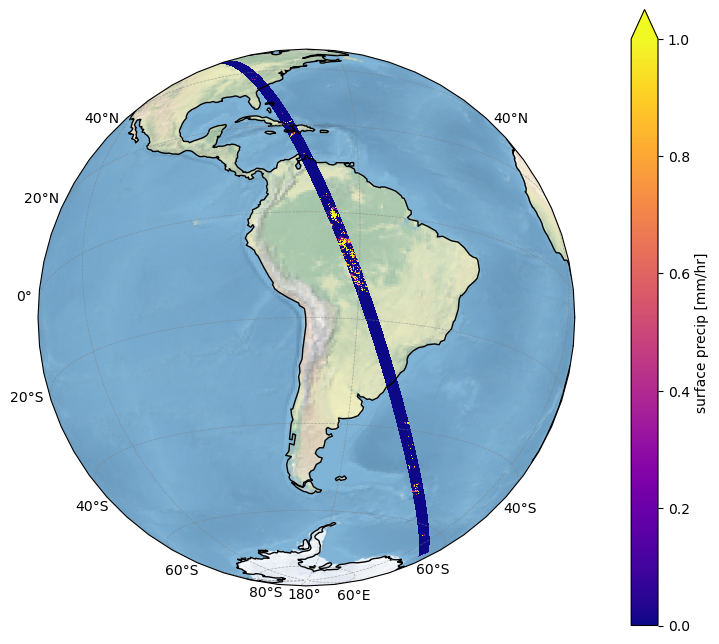

In [5]:
gs = GridSpec(1, 2, width_ratios=[1.0, 0.05])
fig = plt.figure(figsize=(8, 8))
cmap = get_cmap("plasma")
cmap.set_bad("lightgrey")
norm = LogNorm(1e-2,1e1)
lats, lons = granule_ds.latitude.values, granule_ds.longitude.values

proj = ccrs.NearsidePerspective(central_latitude=-20,
                                central_longitude=-70)
ax = plt.subplot(gs[0], projection=proj)
ax.stock_img()
ax.coastlines()
sm = ax.pcolormesh(lons, lats, granule_ds.surface_precip.values, cmap=cmap, vmin = 0, vmax = 1, transform=ccrs.PlateCarree()) 

### add lats and lons for better orientation
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.6,
    linestyle='--'
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

ax = plt.subplot(gs[1])
plt.colorbar(sm, extend = 'max', cax=ax, fraction=0.35, pad=0.2, label="surface precip [mm/hr]")
plt.show()

#### Composite reflectivity

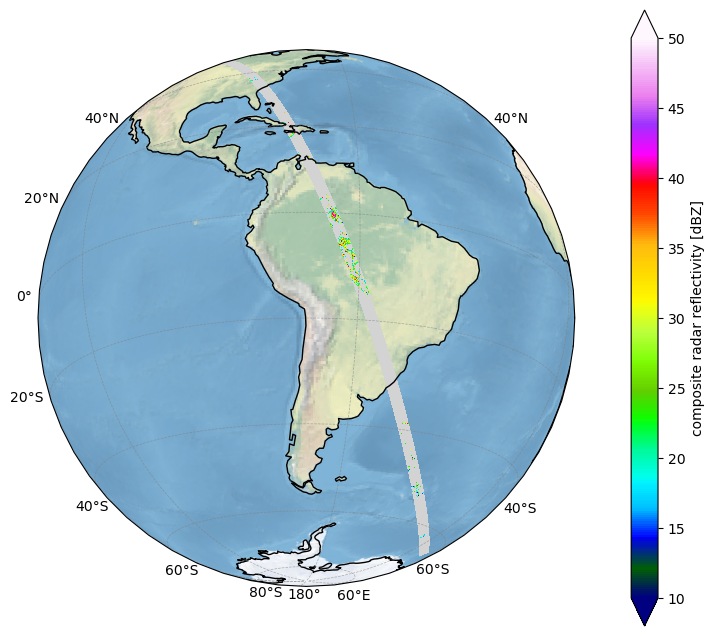

In [6]:
gs = GridSpec(1, 2, width_ratios=[1.0, 0.05])
fig = plt.figure(figsize=(8, 8))
# cmap = get_cmap("magma_r")
cmap = get_cmap("gist_ncar")
cmap.set_bad("lightgrey")

proj = ccrs.NearsidePerspective(central_latitude=-20,
                                central_longitude=-70)
ax = plt.subplot(gs[0], projection=proj)
ax.stock_img()
ax.coastlines()
sm = ax.pcolormesh(lons, lats, granule_ds.reflectivity.max('bins'), cmap=cmap, vmin = 10, vmax = 50, transform=ccrs.PlateCarree()) 

### add lats and lons for better orientation
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.6,
    linestyle='--')

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

ax = plt.subplot(gs[1])
plt.colorbar(sm, extend = 'both', cax=ax, fraction=0.35, pad=0.2, label="composite radar reflectivity [dBZ]")
plt.show()

## Visualization of regridded data

In [3]:
# read in regridded zarr file 
from pathlib import Path 
import xarray as xr 
path = Path('/glade/derecho/scratch/kukulies/gpm_dpr/202002/')
filename = path / 'GPM_DPR_reflectivity_regridded_2020-02-28.zarr'
ds_regridded = xr.open_zarr(filename, consolidated = False) 
lats, lons = ds_regridded.lat.values, ds_regridded.lon.values
granule= 11 # pick the granule that corresponds to the source file above , e.g. 11 
rrefl = ds_regridded.reflectivity[granule].compute()
comp_refl = ds_regridded.column_max_reflectivity[granule].compute()
mean_refl = ds_regridded.reflectivity.mean('bin').[granule].compute()
print('Granule ' + str(granule) +', start:', rrefl.scan_time_start.compute().data, 'end: ',  rrefl.scan_time_end.compute().data)
swath_edge = ds_regridded.swath_edge[granule].compute()

Granule 11, start: 2020-02-28T15:39:09.364000000 end:  2020-02-28T17:11:43.856000000


The regridded data has the following dimensions: **(time: 16 , lat: 3298, lon: 9896, height: 176)**

The timesteps are for each of the 15-16 granules in the specific day. 

In [17]:
mean_refl = ds_regridded.reflectivity.mean('height')[granule].compute()

In [8]:
print(ds_regridded.time.values)

['2020-02-28T00:00:00.000000000' '2020-02-28T01:00:00.000000000'
 '2020-02-28T03:00:00.000000000' '2020-02-28T04:00:00.000000000'
 '2020-02-28T06:00:00.000000000' '2020-02-28T07:00:00.000000000'
 '2020-02-28T09:00:00.000000000' '2020-02-28T10:00:00.000000000'
 '2020-02-28T12:00:00.000000000' '2020-02-28T13:00:00.000000000'
 '2020-02-28T15:00:00.000000000' '2020-02-28T16:00:00.000000000'
 '2020-02-28T18:00:00.000000000' '2020-02-28T20:00:00.000000000'
 '2020-02-28T21:00:00.000000000' '2020-02-28T22:00:00.000000000']


In [9]:
ds_regridded

<xarray.Dataset> Size: 374GB
Dimensions:                  (time: 16, lat: 3298, lon: 9896, height: 176)
Coordinates:
  * height                   (height) float32 704B 2.154e+04 ... 0.05814
  * lat                      (lat) float32 13kB -59.98 -59.95 ... 59.95 59.98
  * lon                      (lon) float32 40kB -180.0 -179.9 ... 179.9 180.0
    scan_time_end            (time) datetime64[ns] 128B dask.array<chunksize=(16,), meta=np.ndarray>
    scan_time_start          (time) datetime64[ns] 128B dask.array<chunksize=(16,), meta=np.ndarray>
  * time                     (time) datetime64[ns] 128B 2020-02-28 ... 2020-0...
Data variables:
    column_max_reflectivity  (time, lat, lon) float32 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    reflectivity             (time, lat, lon, height) float32 368GB dask.array<chunksize=(1, 512, 512, 176), meta=np.ndarray>
    swath_edge               (time, lat, lon) int64 4GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>

In [10]:
swath_edge

<xarray.DataArray 'swath_edge' (lat: 3298, lon: 9896)> Size: 261MB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])
Coordinates:
  * lat              (lat) float32 13kB -59.98 -59.95 -59.91 ... 59.95 59.98
  * lon              (lon) float32 40kB -180.0 -179.9 -179.9 ... 179.9 180.0
    scan_time_end    datetime64[ns] 8B 2020-02-28T17:11:43.856000
    scan_time_start  datetime64[ns] 8B 2020-02-28T15:39:09.364000
    time             datetime64[ns] 8B 2020-02-28T16:00:00

#### Satellite swath edge for a specific overpass - zoom in for better visualization

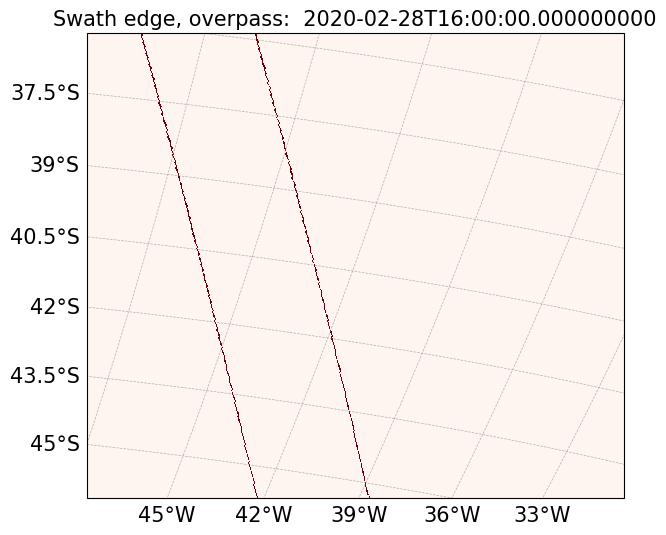

In [11]:
gs = GridSpec(1, 2, width_ratios=[1.0, 0.05])

fig = plt.figure(figsize=(8, 8))
cmap = get_cmap("magma_r")
cmap.set_bad((0, 0, 0, 0)) 
cmap.set_under("lightgrey")
fs = 15
proj = ccrs.NearsidePerspective(central_latitude = -20,
                                central_longitude = -70)

ax = plt.subplot(gs[0], projection=proj)
ax.stock_img()
ax.coastlines()
sm = ax.pcolormesh(lons, lats, swath_edge,  cmap='Reds', transform=ccrs.PlateCarree()) 
# zoom in (for better visualization of the swath) 
# ax.set_extent([-50,-40, -45, -35])
ax.set_extent([-48, -36, -45, -36])

### add lats and lons for better orientation
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.6,
    linestyle='--')

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': fs}
gl.ylabel_style = {'size': fs}
plt.title('Swath edge, overpass:  ' + str(ds_regridded.time[granule].data), fontsize = fs )
plt.show()

Checking swath_edge at lat=-38.9873° (index 577), lon=[-48.0, -42.5]
  # edge pixels (value=1): 2
  # non-edge pixels (value=0): 149
  Unique values: [0 1]

  Lon(s) of edge pixels: [-47.71019  -44.363373]


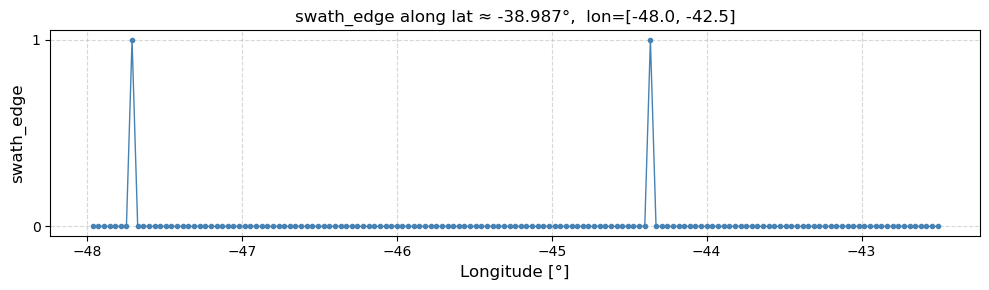

In [12]:

# ---- Check swath_edge along a given latitude slice ----
check_lat  = -39.0
lon_min    = -48.0
lon_max    = -42.5

# Find nearest lat index
lat_idx = np.argmin(np.abs(lats - check_lat))
actual_lat = lats[lat_idx]

# Subset the lon range
lon_mask    = (lons >= lon_min) & (lons <= lon_max)
edge_slice  = swath_edge.values[lat_idx, lon_mask]
lons_subset = lons[lon_mask]

print(f"Checking swath_edge at lat={actual_lat:.4f}° (index {lat_idx}), "
      f"lon=[{lon_min}, {lon_max}]")
print(f"  # edge pixels (value=1): {(edge_slice == 1).sum()}")
print(f"  # non-edge pixels (value=0): {(edge_slice == 0).sum()}")
print(f"  Unique values: {np.unique(edge_slice)}")
print()

# Show lon positions where swath_edge == 1
edge_lons = lons_subset[edge_slice == 1]
print(f"  Lon(s) of edge pixels: {edge_lons}")

# Quick line plot for visual confirmation
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(lons_subset, edge_slice, marker='o', markersize=3, linewidth=1, color='steelblue')
ax.set_xlabel('Longitude [°]', fontsize=12)
ax.set_ylabel('swath_edge', fontsize=12)
ax.set_title(f'swath_edge along lat ≈ {actual_lat:.3f}°,  lon=[{lon_min}, {lon_max}]', fontsize=12)
ax.set_yticks([0, 1])
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


#### Composite reflectivity 

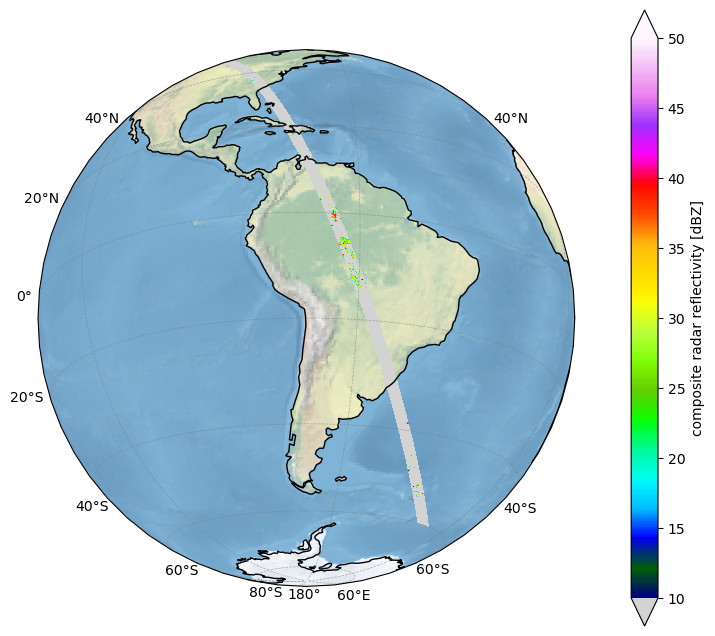

In [13]:
gs = GridSpec(1, 2, width_ratios=[1.0, 0.05])
fig = plt.figure(figsize=(8, 8))
# cmap = get_cmap("magma_r")
cmap = get_cmap("gist_ncar")
cmap.set_bad((0, 0, 0, 0)) 
cmap.set_under("lightgrey")

proj = ccrs.NearsidePerspective(central_latitude = -20,
                                central_longitude = -70)

ax = plt.subplot(gs[0], projection=proj)
ax.stock_img()
ax.coastlines()
sm = ax.pcolormesh(lons, lats, comp_refl,  cmap=cmap, vmin = 10, vmax = 50, transform=ccrs.PlateCarree()) 

### add lats and lons for better orientation
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.6,
    linestyle='--')

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

ax = plt.subplot(gs[1])
plt.colorbar(sm, extend = 'both', cax=ax, fraction=0.35, pad=0.2, label="composite radar reflectivity [dBZ]")
plt.show()

## Compare the original granule and regridded reflectivity

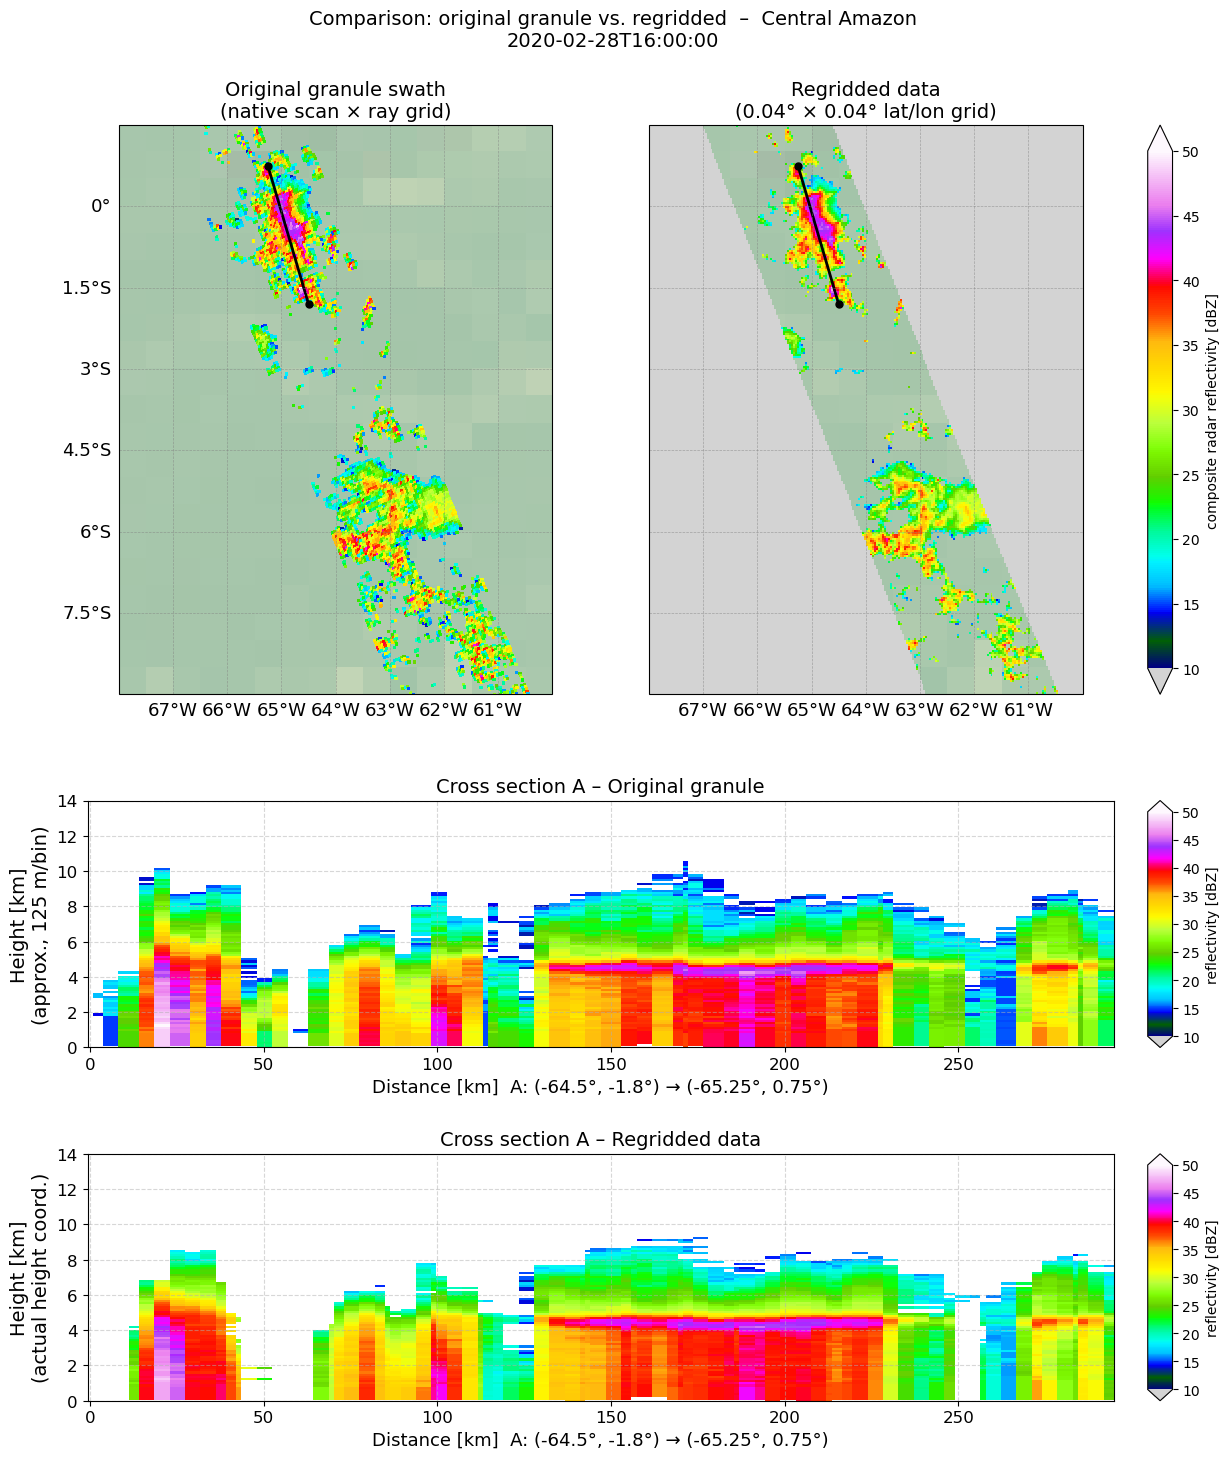

In [4]:
from scipy.spatial import cKDTree

# ---- Cross section A endpoints ----
lon1_A, lat1_A = -64.5, -1.8
lon2_A, lat2_A = -65.25, 0.75
n_pts_cs       = 200
compare_extent = [-68, -60, -9, 1.5]
ylim_km        = 14
fs             = 14

cmap_cmp = get_cmap("gist_ncar")
cmap_cmp.set_bad((0, 0, 0, 0))
cmap_cmp.set_under("lightgrey")

# ---- Cross section sample points and along-track distance ----
lons_cs = np.linspace(lon1_A, lon2_A, n_pts_cs)
lats_cs = np.linspace(lat1_A, lat2_A, n_pts_cs)
dlons   = np.diff(lons_cs)
dlats   = np.diff(lats_cs)
dist_cs = np.concatenate([[0], np.cumsum(
    np.sqrt((dlons * 111.32 * np.cos(np.deg2rad(lats_cs[:-1])))**2 +
            (dlats * 110.54)**2))])

# ---- 2-D composite reflectivity from original granule ----
lats_src      = granule_ds.latitude.values   # (scans, rays)
lons_src      = granule_ds.longitude.values
comp_refl_src = granule_ds.reflectivity.max('bins').values

# ---- Original granule cross section: nearest-neighbor via KD-tree ----
valid    = np.isfinite(lats_src.ravel()) & np.isfinite(lons_src.ravel())
vi       = np.where(valid)[0]
tree_src = cKDTree(np.column_stack([lats_src.ravel()[vi],
                                    lons_src.ravel()[vi]]))
_, nn        = tree_src.query(np.column_stack([lats_cs, lons_cs]))
flat_idx     = vi[nn]
scan_idx     = flat_idx // lats_src.shape[1]
ray_idx      = flat_idx %  lats_src.shape[1]

cs_src = granule_ds.reflectivity.values[scan_idx, ray_idx, :].astype(float)
cs_src[cs_src < -100] = np.nan

# DPR: 176 bins × 125 m/bin, bin 0 = top → flip so index 0 = surface
n_bins        = cs_src.shape[1]
cs_src_flip   = np.flip(cs_src, axis=-1)
height_src_km = np.arange(n_bins) * 0.125   # 0 → ~21.875 km

# ---- Regridded cross section: xarray interp ----
heights_km_rg = ds_regridded.height.values / 1000.0

cs_rg = rrefl.interp(
    lon=xr.DataArray(lons_cs, dims='points'),
    lat=xr.DataArray(lats_cs, dims='points'),
    method='nearest'
).compute().values.astype(float)
cs_rg[cs_rg < -100] = np.nan
cs_rg_flip   = np.flip(cs_rg, axis=-1)
height_rg_km = np.flip(heights_km_rg)       # surface → top

# ---- Figure layout: derive sizes from the map extent aspect ratio ----
# lat_span / lon_span gives the natural portrait aspect of each map panel.
_map_aspect = ((compare_extent[3] - compare_extent[2]) /
               (compare_extent[1] - compare_extent[0]))   # 10.5 / 8 = 1.3125

_fig_width  = 14.0
_xs_row_h   = 3.5   # desired height of each cross-section row [inches]

# Usable width per map panel: subtract colorbar column (0.05 ratio-units out of
# total 2.05) and wspace (10% of avg column width).
_map_col_w  = _fig_width * (1.0 / (1.0 + 1.0 + 0.05)) * (1.0 - 0.10)
_map_row_h  = _map_col_w * _map_aspect          # height that fills the panel width
_fig_height = _map_row_h + 2 * _xs_row_h + 1.5  # +1.5" for hspace & margins
_hr_map     = _map_row_h / _xs_row_h             # height ratio relative to xs rows

fig = plt.figure(figsize=(_fig_width, _fig_height))
gs  = GridSpec(3, 3, width_ratios=[1.0, 1.0, 0.05],
               height_ratios=[_hr_map, 1.0, 1.0],
               hspace=0.30, wspace=0.10, figure=fig)

proj = ccrs.PlateCarree()

# ── Row 0: composite reflectivity maps ─────────────────────────────────────
ax_l = plt.subplot(gs[0, 0], projection=proj)
ax_l.stock_img()
ax_l.coastlines(resolution='50m', linewidth=0.8)
sm_map = ax_l.pcolormesh(lons_src, lats_src, comp_refl_src,
                         cmap=cmap_cmp, vmin=10, vmax=50,
                         transform=ccrs.PlateCarree())
ax_l.set_extent(compare_extent, crs=ccrs.PlateCarree())
ax_l.plot([lon1_A, lon2_A], [lat1_A, lat2_A], 'k-', linewidth=2,
          transform=ccrs.PlateCarree())
ax_l.plot([lon1_A, lon2_A], [lat1_A, lat2_A], 'ko', markersize=5,
          transform=ccrs.PlateCarree())
gl_l = ax_l.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl_l.top_labels = False; gl_l.right_labels = False
gl_l.xlabel_style = {'size': fs - 1}; gl_l.ylabel_style = {'size': fs - 1}
ax_l.set_title('Original granule swath\n(native scan × ray grid)', fontsize=fs)

ax_r = plt.subplot(gs[0, 1], projection=proj)
ax_r.stock_img()
ax_r.coastlines(resolution='50m', linewidth=0.8)
sm_map2 = ax_r.pcolormesh(lons, lats, comp_refl.values,
                          cmap=cmap_cmp, vmin=10, vmax=50,
                          transform=ccrs.PlateCarree())
ax_r.set_extent(compare_extent, crs=ccrs.PlateCarree())
ax_r.plot([lon1_A, lon2_A], [lat1_A, lat2_A], 'k-', linewidth=2,
          transform=ccrs.PlateCarree())
ax_r.plot([lon1_A, lon2_A], [lat1_A, lat2_A], 'ko', markersize=5,
          transform=ccrs.PlateCarree())
gl_r = ax_r.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl_r.top_labels = False; gl_r.right_labels = False; gl_r.left_labels = False
gl_r.xlabel_style = {'size': fs - 1}; gl_r.ylabel_style = {'size': fs - 1}
ax_r.set_title('Regridded data\n(0.04° × 0.04° lat/lon grid)', fontsize=fs)

ax_cb0 = plt.subplot(gs[0, 2])
plt.colorbar(sm_map, extend='both', cax=ax_cb0,
             label="composite radar reflectivity [dBZ]")

# ── Row 1: cross section – original granule (full width) ───────────────────
ax_xs_l = plt.subplot(gs[1, 0:2])
sm_xs_l = ax_xs_l.pcolormesh(dist_cs, height_src_km, cs_src_flip.T,
                              cmap=cmap_cmp, vmin=10, vmax=50, shading='auto')
ax_xs_l.set_ylim(0, ylim_km)
ax_xs_l.set_xlabel(f'Distance [km]  A: ({lon1_A}°, {lat1_A}°) → ({lon2_A}°, {lat2_A}°)',
                   fontsize=fs - 1)
ax_xs_l.set_ylabel('Height [km]\n(approx., 125 m/bin)', fontsize=fs)
ax_xs_l.set_title('Cross section A – Original granule', fontsize=fs)
ax_xs_l.tick_params(labelsize=fs - 2)
ax_xs_l.grid(True, linestyle='--', alpha=0.5)

ax_cb1 = plt.subplot(gs[1, 2])
plt.colorbar(sm_xs_l, extend='both', cax=ax_cb1, label="reflectivity [dBZ]")

# ── Row 2: cross section – regridded data (full width) ─────────────────────
ax_xs_r = plt.subplot(gs[2, 0:2])
sm_xs_r = ax_xs_r.pcolormesh(dist_cs, height_rg_km, cs_rg_flip.T,
                              cmap=cmap_cmp, vmin=10, vmax=50, shading='auto')
ax_xs_r.set_ylim(0, ylim_km)
ax_xs_r.set_xlabel(f'Distance [km]  A: ({lon1_A}°, {lat1_A}°) → ({lon2_A}°, {lat2_A}°)',
                   fontsize=fs - 1)
ax_xs_r.set_ylabel('Height [km]\n(actual height coord.)', fontsize=fs)
ax_xs_r.set_title('Cross section A – Regridded data', fontsize=fs)
ax_xs_r.tick_params(labelsize=fs - 2)
ax_xs_r.grid(True, linestyle='--', alpha=0.5)

ax_cb2 = plt.subplot(gs[2, 2])
plt.colorbar(sm_xs_r, extend='both', cax=ax_cb2, label="reflectivity [dBZ]")

plt.suptitle('Comparison: original granule vs. regridded  –  Central Amazon\n' +
             str(rrefl.time.values)[0:-10], fontsize=fs, y=0.95)
plt.show()


## Compare the means instead of max: 

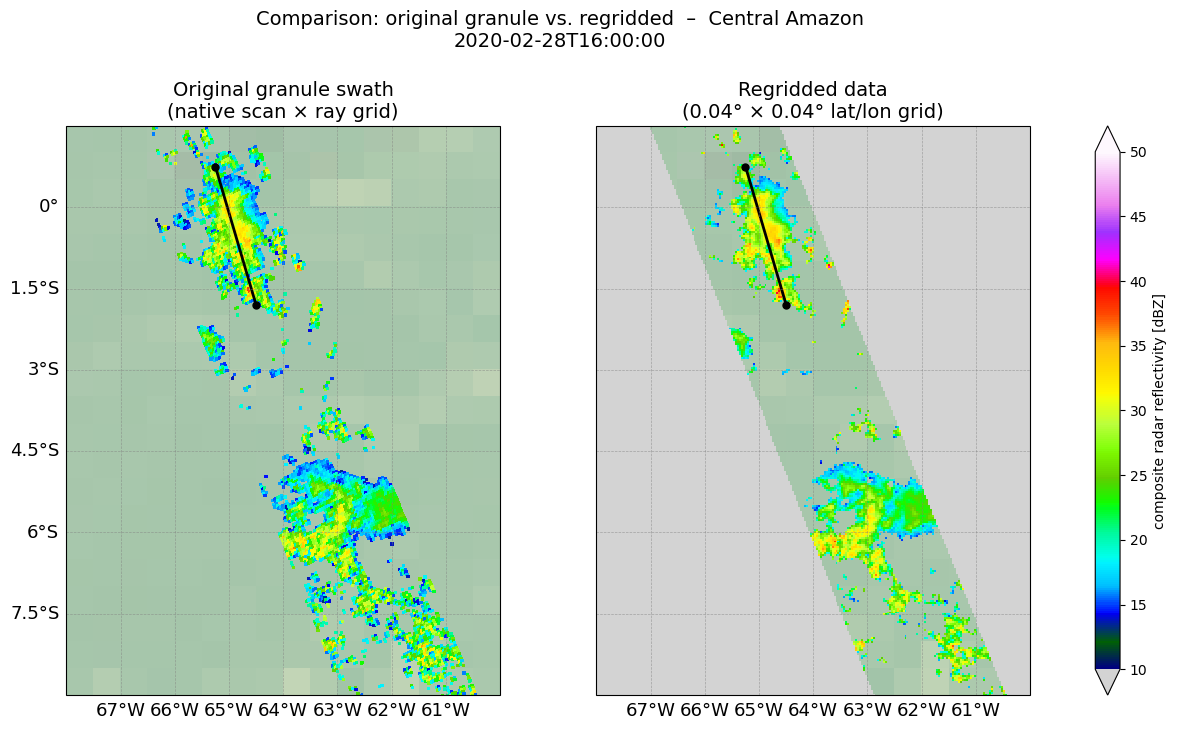

In [18]:
from scipy.spatial import cKDTree

# ---- Cross section A endpoints ----
lon1_A, lat1_A = -64.5, -1.8
lon2_A, lat2_A = -65.25, 0.75
n_pts_cs       = 200
compare_extent = [-68, -60, -9, 1.5]
ylim_km        = 14
fs             = 14

cmap_cmp = get_cmap("gist_ncar")
cmap_cmp.set_bad((0, 0, 0, 0))
cmap_cmp.set_under("lightgrey")

# ---- Cross section sample points and along-track distance ----
lons_cs = np.linspace(lon1_A, lon2_A, n_pts_cs)
lats_cs = np.linspace(lat1_A, lat2_A, n_pts_cs)
dlons   = np.diff(lons_cs)
dlats   = np.diff(lats_cs)
dist_cs = np.concatenate([[0], np.cumsum(
    np.sqrt((dlons * 111.32 * np.cos(np.deg2rad(lats_cs[:-1])))**2 +
            (dlats * 110.54)**2))])

# ---- 2-D composite reflectivity from original granule ----
lats_src      = granule_ds.latitude.values   # (scans, rays)
lons_src      = granule_ds.longitude.values
comp_refl_src = granule_ds.reflectivity.mean('bins').values

# ---- Original granule cross section: nearest-neighbor via KD-tree ----
valid    = np.isfinite(lats_src.ravel()) & np.isfinite(lons_src.ravel())
vi       = np.where(valid)[0]
tree_src = cKDTree(np.column_stack([lats_src.ravel()[vi],
                                    lons_src.ravel()[vi]]))
_, nn        = tree_src.query(np.column_stack([lats_cs, lons_cs]))
flat_idx     = vi[nn]
scan_idx     = flat_idx // lats_src.shape[1]
ray_idx      = flat_idx %  lats_src.shape[1]

cs_src = granule_ds.reflectivity.values[scan_idx, ray_idx, :].astype(float)
cs_src[cs_src < -100] = np.nan

# DPR: 176 bins × 125 m/bin, bin 0 = top → flip so index 0 = surface
n_bins        = cs_src.shape[1]
cs_src_flip   = np.flip(cs_src, axis=-1)
height_src_km = np.arange(n_bins) * 0.125   # 0 → ~21.875 km

# ---- Regridded cross section: xarray interp ----
heights_km_rg = ds_regridded.height.values / 1000.0

cs_rg = rrefl.interp(
    lon=xr.DataArray(lons_cs, dims='points'),
    lat=xr.DataArray(lats_cs, dims='points'),
    method='nearest'
).compute().values.astype(float)
cs_rg[cs_rg < -100] = np.nan
cs_rg_flip   = np.flip(cs_rg, axis=-1)
height_rg_km = np.flip(heights_km_rg)       # surface → top

# ---- Figure layout: derive sizes from the map extent aspect ratio ----
# lat_span / lon_span gives the natural portrait aspect of each map panel.
_map_aspect = ((compare_extent[3] - compare_extent[2]) /
               (compare_extent[1] - compare_extent[0]))   # 10.5 / 8 = 1.3125

_fig_width  = 14.0
_xs_row_h   = 3.5   # desired height of each cross-section row [inches]

# Usable width per map panel: subtract colorbar column (0.05 ratio-units out of
# total 2.05) and wspace (10% of avg column width).
_map_col_w  = _fig_width * (1.0 / (1.0 + 1.0 + 0.05)) * (1.0 - 0.10)
_map_row_h  = _map_col_w * _map_aspect          # height that fills the panel width
_fig_height = _map_row_h + 2 * _xs_row_h + 1.5  # +1.5" for hspace & margins
_hr_map     = _map_row_h / _xs_row_h             # height ratio relative to xs rows

fig = plt.figure(figsize=(_fig_width, _fig_height))
gs  = GridSpec(3, 3, width_ratios=[1.0, 1.0, 0.05],
               height_ratios=[_hr_map, 1.0, 1.0],
               hspace=0.30, wspace=0.10, figure=fig)

proj = ccrs.PlateCarree()

# ── Row 0: composite reflectivity maps ─────────────────────────────────────
ax_l = plt.subplot(gs[0, 0], projection=proj)
ax_l.stock_img()
ax_l.coastlines(resolution='50m', linewidth=0.8)
sm_map = ax_l.pcolormesh(lons_src, lats_src, comp_refl_src,
                         cmap=cmap_cmp, vmin=10, vmax=50,
                         transform=ccrs.PlateCarree())
ax_l.set_extent(compare_extent, crs=ccrs.PlateCarree())
ax_l.plot([lon1_A, lon2_A], [lat1_A, lat2_A], 'k-', linewidth=2,
          transform=ccrs.PlateCarree())
ax_l.plot([lon1_A, lon2_A], [lat1_A, lat2_A], 'ko', markersize=5,
          transform=ccrs.PlateCarree())
gl_l = ax_l.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl_l.top_labels = False; gl_l.right_labels = False
gl_l.xlabel_style = {'size': fs - 1}; gl_l.ylabel_style = {'size': fs - 1}
ax_l.set_title('Original granule swath\n(native scan × ray grid)', fontsize=fs)

ax_r = plt.subplot(gs[0, 1], projection=proj)
ax_r.stock_img()
ax_r.coastlines(resolution='50m', linewidth=0.8)
sm_map2 = ax_r.pcolormesh(lons, lats, mean_refl.values,
                          cmap=cmap_cmp, vmin=10, vmax=50,
                          transform=ccrs.PlateCarree())
ax_r.set_extent(compare_extent, crs=ccrs.PlateCarree())
ax_r.plot([lon1_A, lon2_A], [lat1_A, lat2_A], 'k-', linewidth=2,
          transform=ccrs.PlateCarree())
ax_r.plot([lon1_A, lon2_A], [lat1_A, lat2_A], 'ko', markersize=5,
          transform=ccrs.PlateCarree())
gl_r = ax_r.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl_r.top_labels = False; gl_r.right_labels = False; gl_r.left_labels = False
gl_r.xlabel_style = {'size': fs - 1}; gl_r.ylabel_style = {'size': fs - 1}
ax_r.set_title('Regridded data\n(0.04° × 0.04° lat/lon grid)', fontsize=fs)

ax_cb0 = plt.subplot(gs[0, 2])
plt.colorbar(sm_map, extend='both', cax=ax_cb0,
             label="composite radar reflectivity [dBZ]")


plt.suptitle('Comparison: original granule vs. regridded  –  Central Amazon\n' +
             str(rrefl.time.values)[0:-10], fontsize=fs, y=0.95)
plt.show()


#### Composite reflectivity – zoom in: central Amazon

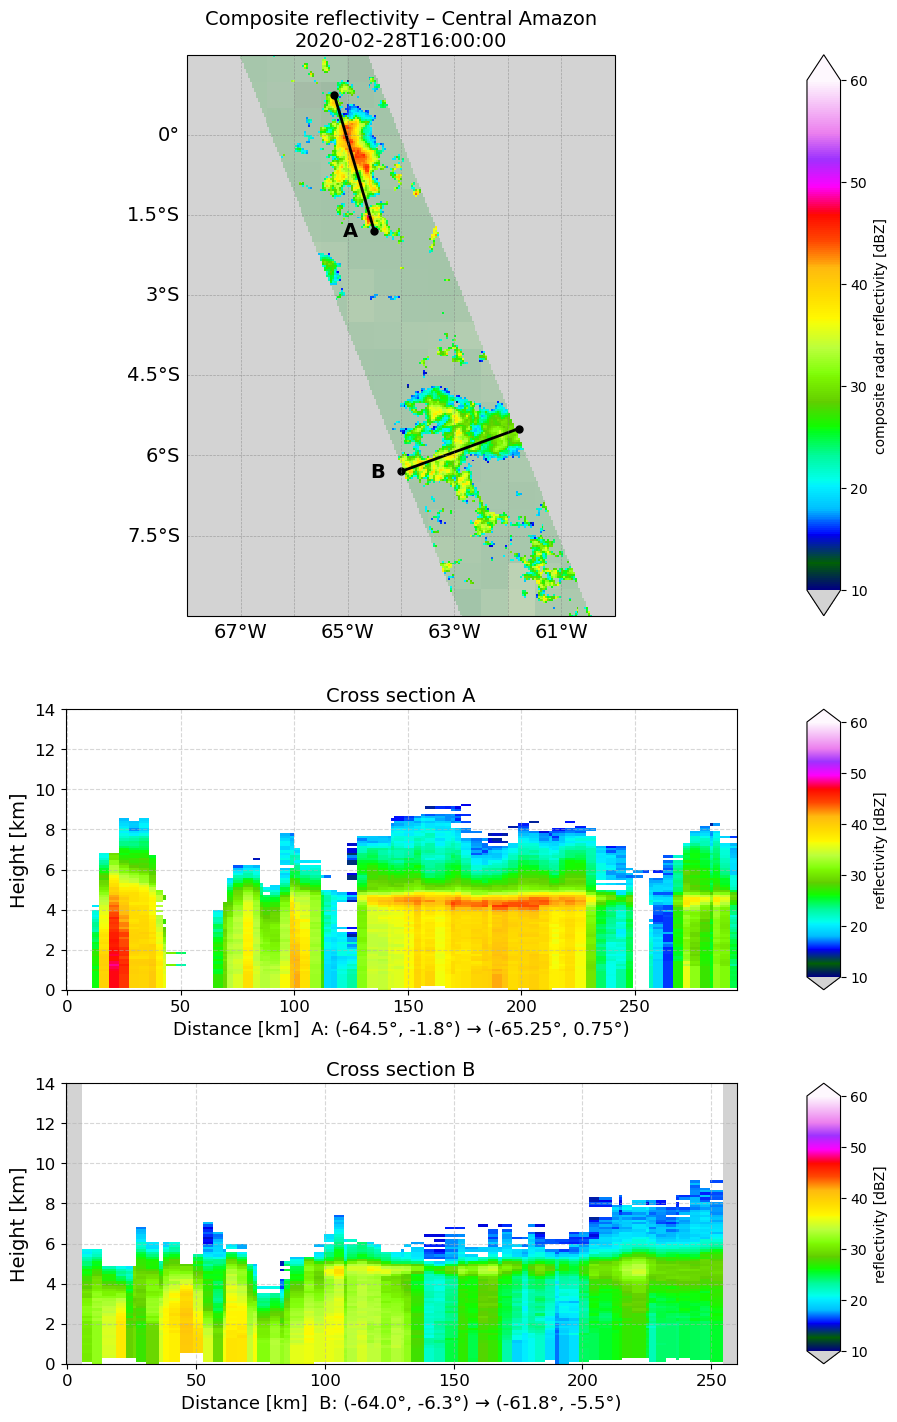

In [5]:
map_extent = [-68, -60, -9, 1.5]

# ---- Cross section A endpoints (lon, lat) ----
lon1_A, lat1_A = -64.5, -1.8  # left endpoint
lon2_A, lat2_A = -65.25, 0.75  # right endpoint

# ---- Cross section B endpoints (lon, lat) ----
lon1_B, lat1_B = -64.0, -6.3   # left endpoint
lon2_B, lat2_B = -61.8, -5.5   # right endpoint

n_pts   = 200   # sample points along each cross section
ylim_km = 14    # upper height limit [km]

heights_km = ds_regridded.height.values / 1000.0  # metres → km

def make_cross_section(rrefl, lon1, lat1, lon2, lat2, n_pts=200):
    """Interpolate 3D reflectivity along a great-circle path; return
    (dist_km, heights_km_flipped, cross_sec_flipped)."""
    lons_cs = np.linspace(lon1, lon2, n_pts)
    lats_cs = np.linspace(lat1, lat2, n_pts)
    cs = rrefl.interp(
        lon=xr.DataArray(lons_cs, dims='points'),
        lat=xr.DataArray(lats_cs, dims='points'),
        method='nearest'
    ).compute()
    dlons   = np.diff(lons_cs)
    dlats   = np.diff(lats_cs)
    dist_km = np.concatenate([[0], np.cumsum(
        np.sqrt((dlons * 111.32 * np.cos(np.deg2rad(lats_cs[:-1])))**2 +
                (dlats * 110.54)**2))])
    cs_flipped = np.flip(cs.values, axis=-1)
    hkm_flip   = np.flip(heights_km)
    return dist_km, hkm_flip, cs_flipped

dist_A, hkm_A, cs_A = make_cross_section(rrefl, lon1_A, lat1_A, lon2_A, lat2_A, n_pts)
dist_B, hkm_B, cs_B = make_cross_section(rrefl, lon1_B, lat1_B, lon2_B, lat2_B, n_pts)

# ---- Figure layout (3 rows: map | xs-A | xs-B) ----
cmap_refl = get_cmap("gist_ncar")
cmap_refl.set_bad((0, 0, 0, 0))
cmap_refl.set_under("lightgrey")
fs = 14

fig = plt.figure(figsize=(10, 17))
gs  = GridSpec(3, 2, width_ratios=[1.0, 0.05],
               height_ratios=[1.4, 0.7, 0.7],
               hspace=0.25, figure=fig)

# ── Top panel: composite reflectivity map ──────────────────────────────────
ax_map = plt.subplot(gs[0, 0], projection=ccrs.PlateCarree())
ax_map.stock_img()
ax_map.coastlines(resolution='50m', linewidth=0.8)
sm = ax_map.pcolormesh(lons, lats, comp_refl, cmap=cmap_refl, vmin=10, vmax=60,
                       transform=ccrs.PlateCarree())
ax_map.set_extent(map_extent, crs=ccrs.PlateCarree())

# Cross-section lines
ax_map.plot([lon1_A, lon2_A], [lat1_A, lat2_A], 'k-', linewidth=2,
            transform=ccrs.PlateCarree())
ax_map.plot([lon1_A, lon2_A], [lat1_A, lat2_A], 'ko', markersize=5,
            transform=ccrs.PlateCarree())
ax_map.text(lon1_A - 0.3, lat1_A, 'A', fontsize=fs, fontweight='bold',
            transform=ccrs.PlateCarree(), va='center', ha='right')

ax_map.plot([lon1_B, lon2_B], [lat1_B, lat2_B], 'k-', linewidth=2,
            transform=ccrs.PlateCarree())
ax_map.plot([lon1_B, lon2_B], [lat1_B, lat2_B], 'ko', markersize=5,
            transform=ccrs.PlateCarree())
ax_map.text(lon1_B - 0.3, lat1_B, 'B', color='k', fontsize=fs, fontweight='bold',
            transform=ccrs.PlateCarree(), va='center', ha='right')

gl = ax_map.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl.top_labels   = False
gl.right_labels = False
gl.xlabel_style = {'size': fs}
gl.ylabel_style = {'size': fs}
ax_map.set_title('Composite reflectivity – Central Amazon\n' +
                 str(rrefl.time.values)[0:-10], fontsize=fs)

ax_cb1 = plt.subplot(gs[0, 1])
plt.colorbar(sm, extend='both', cax=ax_cb1,
             label="composite radar reflectivity [dBZ]")

# ── Middle panel: cross section A ─────────────────────────────────────────
ax_A = plt.subplot(gs[1, 0])
sm2 = ax_A.pcolormesh(dist_A, hkm_A, cs_A.T,
                      cmap=cmap_refl, vmin=10, vmax=60, shading='auto')
ax_A.set_ylim(0, ylim_km)
ax_A.set_xlabel(
    f'Distance [km]  A: ({lon1_A}°, {lat1_A}°) → ({lon2_A}°, {lat2_A}°)',
    fontsize=fs - 1)
ax_A.set_ylabel('Height [km]', fontsize=fs)
ax_A.set_title('Cross section A', fontsize=fs)
ax_A.tick_params(labelsize=fs - 2)
ax_A.grid(True, linestyle='--', alpha=0.5)

ax_cb2 = plt.subplot(gs[1, 1])
plt.colorbar(sm2, extend='both', cax=ax_cb2, label="reflectivity [dBZ]")

# ── Bottom panel: cross section B ─────────────────────────────────────────
ax_B = plt.subplot(gs[2, 0])
sm3 = ax_B.pcolormesh(dist_B, hkm_B, cs_B.T,
                      cmap=cmap_refl, vmin=10, vmax=60, shading='auto')
ax_B.set_ylim(0, ylim_km)
ax_B.set_xlabel(
    f'Distance [km]  B: ({lon1_B}°, {lat1_B}°) → ({lon2_B}°, {lat2_B}°)',
    fontsize=fs - 1)
ax_B.set_ylabel('Height [km]', fontsize=fs)
ax_B.set_title('Cross section B', fontsize=fs)
ax_B.tick_params(labelsize=fs - 2)
ax_B.grid(True, linestyle='--', alpha=0.5)

ax_cb3 = plt.subplot(gs[2, 1])
plt.colorbar(sm3, extend='both', cax=ax_cb3, label="reflectivity [dBZ]")

plt.show()


## Precipitation feature labeling and swath-edge identification

Contiguous precipitation features are detected from `comp_refl > 15 dBZ` and labeled using `scipy.ndimage.label`. Features that touch the swath edge (where `swath_edge == 1`) are then separated from interior features and visualized.


### Step 1: Label contiguous precipitation features

A binary mask is created from `comp_refl > 15 dBZ`. `scipy.ndimage.label` then assigns a unique integer ID to each contiguous group of True pixels using 4-connectivity (default). Fill values (< 0) and NaN are excluded automatically by the threshold comparison.


In [16]:
from scipy.ndimage import label as ndimage_label

# Binary mask: pixels with comp_refl > 15 dBZ
# NaN comparisons return False, and fill values (< 0) are below the threshold,
# so no extra masking is needed.
refl_2d     = comp_refl.values
precip_mask = refl_2d > 15.0

# Label contiguous features using 4-connectivity (default structuring element)
labeled_array, n_features = ndimage_label(precip_mask)
print(f"Total precipitation features (comp_refl > 15 dBZ): {n_features}")


Total precipitation features (comp_refl > 15 dBZ): 689


### Step 2: Identify features that touch the swath edge

For each labeled feature, we check whether any of its pixels coincides with a `swath_edge == 1` pixel. A vectorized approach is used: we index `labeled_array` with the edge-pixel positions and collect the unique non-background feature IDs. Two 2D boolean masks are then constructed — one for edge-touching features and one for interior features.


In [17]:
edge_data = swath_edge.values   # 0 = interior/no-data,  1 = swath-edge pixel

# Vectorized: collect all feature IDs that have at least one edge pixel
# labeled_array[edge_data > 0.5] gives the feature labels at every edge pixel
edge_feature_ids = np.unique(labeled_array[edge_data > 0.5])
edge_feature_ids = edge_feature_ids[edge_feature_ids > 0]   # drop background (label 0)

# 2D boolean masks
edge_feature_mask     = np.isin(labeled_array, edge_feature_ids)        # touches edge
interior_feature_mask = (labeled_array > 0) & ~edge_feature_mask        # does not touch edge

n_edge_features     = len(edge_feature_ids)
n_interior_features = n_features - n_edge_features
print(f"Features touching swath edge : {n_edge_features}")
print(f"Interior (non-edge) features : {n_interior_features}")


Features touching swath edge : 64
Interior (non-edge) features : 625


### Step 3: Visualize features relative to the swath edge

The composite reflectivity map is used as the background. Interior features are overlaid in **blue** at `alpha=0.5`, and edge-touching features in **red** at `alpha=1.0`. Each overlay is a separate `pcolormesh` call with a single-color colormap; `set_bad((0,0,0,0))` makes NaN pixels fully transparent so only labeled feature pixels are colored.


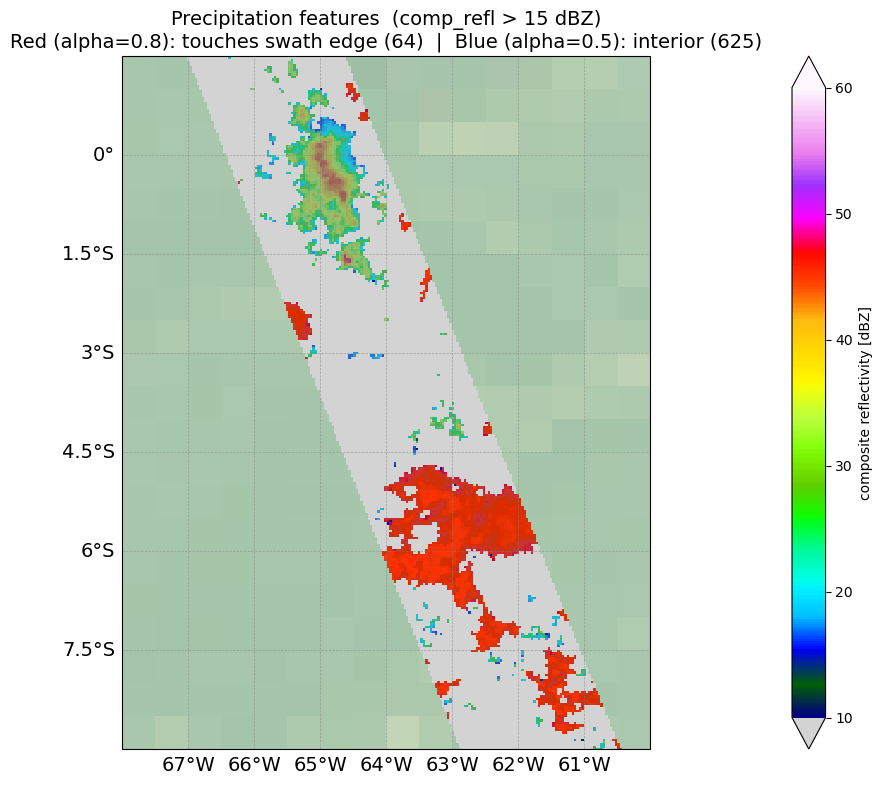

In [18]:
from matplotlib.colors import ListedColormap

feat_map_extent = [-68, -60, -9, 1.5]   # same zoom-in region as cell #23
fs = 14

# ── Background colormap ────────────────────────────────────────────────────
cmap_bg = get_cmap("gist_ncar")
cmap_bg.set_bad((0, 0, 0, 0))
cmap_bg.set_under("lightgrey")

# ── Single-color overlay colormaps ────────────────────────────────────────
# NaN → fully transparent so only labeled pixels are rendered
cmap_interior = ListedColormap(['steelblue'])
cmap_interior.set_bad((0, 0, 0, 0))

cmap_edge = ListedColormap(['red'])
cmap_edge.set_bad((0, 0, 0, 0))

# 2D float arrays: 1.0 on feature pixels, NaN everywhere else
interior_vis = np.where(interior_feature_mask, 1.0, np.nan)
edge_vis     = np.where(edge_feature_mask,     1.0, np.nan)

# ── Plot ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 9))
gs  = GridSpec(1, 2, width_ratios=[1.0, 0.05])

ax = plt.subplot(gs[0], projection=ccrs.PlateCarree())
ax.stock_img()
ax.coastlines(resolution='50m', linewidth=0.8)

# Background: composite reflectivity
sm = ax.pcolormesh(lons, lats, refl_2d, cmap=cmap_bg, vmin=10, vmax=60,
                   transform=ccrs.PlateCarree())
ax.set_extent(feat_map_extent, crs=ccrs.PlateCarree())

# Interior features: semi-transparent blue (alpha=0.5)
ax.pcolormesh(lons, lats, interior_vis, cmap=cmap_interior, vmin=0.5, vmax=1.5,
              transform=ccrs.PlateCarree(), alpha=0.5)

# Edge-touching features: semi-transparent red (alpha=0.8)
ax.pcolormesh(lons, lats, edge_vis, cmap=cmap_edge, vmin=0.5, vmax=1.5,
              transform=ccrs.PlateCarree(), alpha=0.8)

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl.top_labels   = False
gl.right_labels = False
gl.xlabel_style = {'size': fs}
gl.ylabel_style = {'size': fs}

ax.set_title(
    f'Precipitation features  (comp_refl > 15 dBZ)\n'
    f'Red (alpha=0.8): touches swath edge ({n_edge_features})  |  '
    f'Blue (alpha=0.5): interior ({n_interior_features})',
    fontsize=fs)

ax_cb = plt.subplot(gs[1])
plt.colorbar(sm, extend='both', cax=ax_cb, label="composite reflectivity [dBZ]")
plt.show()


In [29]:
cs_src_flip.shape, cs_rg_flip.shape, dist_A.shape

((200, 176), (200, 176), (200,))

In [ ]:

# ---- Vertical profile from cross section A at ~25 km from the left endpoint ----
target_dist_km = 25.0

# Find the index along cross section A closest to target_dist_km
idx_rg = np.argmin(np.abs(dist_A - target_dist_km))
actual_dist_rg = dist_A[idx_rg]

idx_src = np.argmin(np.abs(dist_A - target_dist_km))
actual_dist_src = dist_A[idx_src]

# Corresponding lon/lat
lons_cs_A = np.linspace(lon1_A, lon2_A, n_pts)
lats_cs_A = np.linspace(lat1_A, lat2_A, n_pts)
prof_lon_rg   = lons_cs_A[idx_rg]
prof_lat_rg   = lats_cs_A[idx_rg]

prof_lon_src   = lons_cs_A[idx_src]
prof_lat_src   = lats_cs_A[idx_src]

profile_rg = cs_A[idx_rg, :].copy()   # already flipped: index 0 = surface
profile_src = np.flip(cs_src[idx_src, :].copy()) # flipped: index 0 = surface

# Mask GPM DPR fill values (-9999.9 for missing, ~ -9573 for below-surface)
# These are numeric, not NaN, so set_bad won't catch them; replace with NaN.
# profile_rg[profile_rg < -100] = np.nan

fig, ax = plt.subplots(figsize=(5, 7))
ax.plot(profile_rg, hkm_A, color='steelblue', linewidth=1.8, label='Regridded data')
ax.plot(profile_src, hkm_A, color='orange', linewidth=1.8, label='Source data')
ax.set_xlim(10, 60)
ax.set_ylim(0, ylim_km)
ax.set_xlabel('Reflectivity [dBZ]', fontsize=fs)
ax.set_ylabel('Height [km]', fontsize=fs)
ax.set_title(
    f'Vertical profile – Cross section A\n'
    f'@ {actual_dist_rg:.1f} km  ({prof_lon_rg:.2f}°, {prof_lat_rg:.2f}°)',
    fontsize=fs)
ax.grid(True, linestyle='--', alpha=0.5)
ax.tick_params(labelsize=fs - 2)
ax.legend(fontsize=fs - 2)
plt.tight_layout()
plt.show()

In [14]:
profile_rg[profile_rg > 0]

array([45.069305, 45.072853, 45.073277, 45.062836, 45.060764, 45.065777,
       45.452637, 45.476746, 45.539505, 46.078968, 45.279808, 45.44308 ,
       44.479855, 45.422386, 45.199978, 45.474964, 45.328587, 44.222576,
       44.288418, 44.192566, 43.58087 , 44.599007, 44.634586, 43.463158,
       42.103   , 42.930737, 42.938683, 41.713177, 42.335537, 42.201366,
       41.403297, 40.893528, 41.047237, 40.999348, 40.12184 , 39.656475,
       40.329132, 39.378654, 38.535286, 37.916203, 37.301662, 36.066093,
       36.204964, 34.915695, 34.12009 , 33.824806, 32.84306 , 31.244865,
       31.515572, 30.493824, 29.29901 , 28.051657, 27.154587, 26.693897,
       25.94118 , 26.315565, 25.907215, 24.582907, 23.550177, 23.648132,
       22.654306, 21.5462  , 21.084019, 20.192999, 21.206335, 19.903305,
       19.290157, 18.811918, 18.007895], dtype=float32)

In [13]:
profile_src[profile_src > 0]

array([45.04999924, 45.06000137, 45.06000137, 45.04000092, 45.04000092,
       45.04999924, 45.70999908, 45.65999985, 45.56000137, 45.86000061,
       45.09999847, 45.75      , 44.25      , 45.29999924, 45.22000122,
       45.81999969, 45.65999985, 44.15999985, 44.16999817, 43.81999969,
       43.11999893, 44.91999817, 45.16999817, 43.70000076, 41.65000153,
       43.11999893, 42.81999969, 41.15000153, 41.93000031, 42.36999893,
       41.04999924, 40.83000183, 40.93000031, 40.72999954, 39.81000137,
       39.61999893, 40.15000153, 38.90999985, 38.41999817, 37.95000076,
       37.11000061, 35.61999893, 36.22000122, 34.70999908, 33.93000031,
       33.84000015, 33.13000107, 31.61000061, 31.92000008, 30.40999985,
       28.89999962, 26.94000053, 26.5       , 25.70000076, 24.39999962,
       25.21999931, 24.79000092, 23.45000076, 22.01000023, 22.51000023,
       20.98999977, 19.17000008, 19.15999985, 18.48999977, 19.12999916,
       17.77000046, 16.96999931, 16.04999924, 14.90999985])

In [35]:
profile_src
# # profile
# profile = cs_A[idx, :].copy()
# profile

array([        nan, 45.04999924, 45.06000137, 45.06000137, 45.04000092,
       45.04000092, 45.04999924, 45.70999908, 45.65999985, 45.56000137,
       45.86000061, 45.09999847, 45.75      , 44.25      , 45.29999924,
       45.22000122, 45.81999969, 45.65999985, 44.15999985, 44.16999817,
       43.81999969, 43.11999893, 44.91999817, 45.16999817, 43.70000076,
       41.65000153, 43.11999893, 42.81999969, 41.15000153, 41.93000031,
       42.36999893, 41.04999924, 40.83000183, 40.93000031, 40.72999954,
       39.81000137, 39.61999893, 40.15000153, 38.90999985, 38.41999817,
       37.95000076, 37.11000061, 35.61999893, 36.22000122, 34.70999908,
       33.93000031, 33.84000015, 33.13000107, 31.61000061, 31.92000008,
       30.40999985, 28.89999962, 26.94000053, 26.5       , 25.70000076,
       24.39999962, 25.21999931, 24.79000092, 23.45000076, 22.01000023,
       22.51000023, 20.98999977, 19.17000008, 19.15999985, 18.48999977,
       19.12999916, 17.77000046, 16.96999931, 16.04999924, 14.90

In [10]:
profile_src

array([        nan, 45.04999924, 45.06000137, 45.06000137, 45.04000092,
       45.04000092, 45.04999924, 45.70999908, 45.65999985, 45.56000137,
       45.86000061, 45.09999847, 45.75      , 44.25      , 45.29999924,
       45.22000122, 45.81999969, 45.65999985, 44.15999985, 44.16999817,
       43.81999969, 43.11999893, 44.91999817, 45.16999817, 43.70000076,
       41.65000153, 43.11999893, 42.81999969, 41.15000153, 41.93000031,
       42.36999893, 41.04999924, 40.83000183, 40.93000031, 40.72999954,
       39.81000137, 39.61999893, 40.15000153, 38.90999985, 38.41999817,
       37.95000076, 37.11000061, 35.61999893, 36.22000122, 34.70999908,
       33.93000031, 33.84000015, 33.13000107, 31.61000061, 31.92000008,
       30.40999985, 28.89999962, 26.94000053, 26.5       , 25.70000076,
       24.39999962, 25.21999931, 24.79000092, 23.45000076, 22.01000023,
       22.51000023, 20.98999977, 19.17000008, 19.15999985, 18.48999977,
       19.12999916, 17.77000046, 16.96999931, 16.04999924, 14.90